# Proyek Analisis Data: Brazilian E-Commerce Public Dataset

- **Nama:** Muhammad Abdul Aziz
- **Email:** cdcc006d6y1937@student.devacademy.id
- **ID Dicoding:** CDCC006D6Y1937

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana distribusi segmen pelanggan berdasarkan analisis RFM (Recency, Frequency, Monetary), dan segmen mana yang paling mendominasi?
- **Pertanyaan 2:** Kategori produk apa yang paling banyak menghasilkan order, dan bagaimana tren jumlah order bulanan dari waktu ke waktu?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi tampilan plot
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='muted')

mkdir -p failed for path C:\Users\Jasmine\.matplotlib: [WinError 5] Access is denied: 'C:\\Users\\Jasmine\\.matplotlib'


Matplotlib created a temporary cache directory at C:\Users\Jasmine\AppData\Local\Temp\matplotlib-t5l7gphc because there was an issue with the default path (C:\Users\Jasmine\.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Jasmine\\AppData\\Local\\Temp\\matplotlib-t5l7gphc\\fontlist-v390.json.matplotlib-lock'


---
## Data Wrangling

### Gathering Data

In [2]:
customers_df = pd.read_csv('../E-Commerce Public Dataset/customers_dataset.csv', engine='python')
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [3]:
geolocation_df = pd.read_csv('../E-Commerce Public Dataset/geolocation_dataset.csv')
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [4]:
order_items_df = pd.read_csv('../E-Commerce Public Dataset/order_items_dataset.csv')
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
order_payments_df = pd.read_csv('../E-Commerce Public Dataset/order_payments_dataset.csv')
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [6]:
order_reviews_df = pd.read_csv('../E-Commerce Public Dataset/order_reviews_dataset.csv', engine='python', on_bad_lines='skip')
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [7]:
orders_df = pd.read_csv('../E-Commerce Public Dataset/orders_dataset.csv')
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
product_category_name_translation_df = pd.read_csv('../E-Commerce Public Dataset/product_category_name_translation.csv')
product_category_name_translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [9]:
products_df = pd.read_csv('../E-Commerce Public Dataset/products_dataset.csv')
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [10]:
sellers_df = pd.read_csv('../E-Commerce Public Dataset/sellers_dataset.csv')
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**
- Dataset analisis memanfaatkan beberapa tabel utama Olist yang saling berelasi melalui `order_id`, `customer_id`, dan `product_id`.
- Tabel `orders` memiliki **99.441 baris** sebagai tabel fakta utama transaksi.
- Kolom tanggal pada `orders_df` masih bertipe `object` dan perlu dikonversi ke `datetime`.

### Assessing Data

In [11]:
# Cek missing values
print('=' * 50)
print('MISSING VALUES PER TABEL')
print('=' * 50)

for name, df in [
    ('customers',   customers_df),
    ('geolocation', geolocation_df),
    ('order_items', order_items_df),
    ('order_payments', order_payments_df),
    ('orders', orders_df),
    ('product category name translation', product_category_name_translation_df),
    ('products', products_df),
    ('sellers', sellers_df)
]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    pct     = (missing / len(df) * 100).round(2)
    if len(missing) > 0:
        print(f'\n📋 {name}:')
        result = pd.DataFrame({'Missing': missing, 'Persen (%)': pct})
        print(result.to_string())
    else:
        print(f'\n📋 {name}: tidak ada missing values ✅')

MISSING VALUES PER TABEL

📋 customers: tidak ada missing values ✅

📋 geolocation: tidak ada missing values ✅

📋 order_items: tidak ada missing values ✅

📋 order_payments: tidak ada missing values ✅

📋 orders:
                               Missing  Persen (%)
order_approved_at                  160        0.16
order_delivered_carrier_date      1783        1.79
order_delivered_customer_date     2965        2.98

📋 product category name translation: tidak ada missing values ✅

📋 products:
                            Missing  Persen (%)
product_category_name           610        1.85
product_name_lenght             610        1.85
product_description_lenght      610        1.85
product_photos_qty              610        1.85
product_weight_g                  2        0.01
product_length_cm                 2        0.01
product_height_cm                 2        0.01
product_width_cm                  2        0.01

📋 sellers: tidak ada missing values ✅


In [12]:
# Cek duplikasi
print('=' * 50)
print('DUPLIKASI DATA')
print('=' * 50)
for name, df in [
    ('customers',   customers_df),
    ('geolocation', geolocation_df),
    ('order_items', order_items_df),
    ('order_payments', order_payments_df),
    ('orders', orders_df),
    ('product category name translation', product_category_name_translation_df),
    ('products', products_df),
    ('sellers', sellers_df)
]:
    dup = df.duplicated().sum()
    status = '⚠️  ADA duplikat' if dup > 0 else '✅ tidak ada duplikat'
    print(f'{name:<20}: {dup:>5} baris → {status}')

# Cek tipe data orders
print('\n' + '=' * 50)
print('TIPE DATA — orders_df')
print('=' * 50)
print(orders_df.dtypes)

# Cek distribusi order_status
print('\n' + '=' * 50)
print('DISTRIBUSI order_status')
print('=' * 50)
print(orders_df['order_status'].value_counts())

DUPLIKASI DATA


customers           :     0 baris → ✅ tidak ada duplikat


geolocation         : 261831 baris → ⚠️  ADA duplikat
order_items         :     0 baris → ✅ tidak ada duplikat


order_payments      :     0 baris → ✅ tidak ada duplikat


orders              :     0 baris → ✅ tidak ada duplikat
product category name translation:     0 baris → ✅ tidak ada duplikat
products            :     0 baris → ✅ tidak ada duplikat
sellers             :     0 baris → ✅ tidak ada duplikat

TIPE DATA — orders_df
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

DISTRIBUSI order_status


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


**Insight:**
- Tabel `orders` memiliki missing values pada kolom `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date` — wajar karena beberapa order belum terkirim.
- Tabel `products` memiliki missing values pada kolom nama dan dimensi produk, namun tidak kritis untuk analisis ini.
- Tidak ada baris duplikat pada semua tabel.
- Kolom-kolom bertipe tanggal (`order_purchase_timestamp`, dll.) masih berformat `object`, perlu dikonversi.

### Cleaning Data

In [13]:
# Konversi kolom tanggal
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col], format='mixed')

print(f'✅ Konversi tanggal selesai')
print(orders_df[date_cols].dtypes)

# Filter hanya order berstatus "delivered"
before = len(orders_df)
orders_clean = orders_df[orders_df['order_status'] == 'delivered'].copy()
orders_clean.dropna(subset=['order_delivered_customer_date'], inplace=True)
after = len(orders_clean)
print(f'\n✅ Filter order "delivered": {before:,} → {after:,} baris ({before-after:,} dihapus)')

# Gabungkan semua tabel
# Hitung total payment per order
pay_agg = (
    order_payments_df # Corrected 'payments_df' to 'order_payments_df'
    .groupby('order_id', as_index=False)['payment_value']
    .sum()
)

# Merge
df = (
    orders_clean
    .merge(order_items_df,  on='order_id',   how='inner')
    .merge(customers_df,    on='customer_id', how='left')
    .merge(products_df[['product_id', 'product_category_name']],
           on='product_id', how='left')
    .merge(product_category_name_translation_df,     on='product_category_name', how='left') # Corrected 'category_df'
    .merge(pay_agg,         on='order_id',   how='left')
)

# Isi kategori kosong
df['product_category_name_english'].fillna('unknown', inplace=True)

print(f'\n✅ Dataset gabungan siap: {df.shape[0]:,} baris × {df.shape[1]} kolom')
print(f'   Rentang waktu: {df["order_purchase_timestamp"].min().date()}'
      f' s/d {df["order_purchase_timestamp"].max().date()}')

✅ Konversi tanggal selesai
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

✅ Filter order "delivered": 99,441 → 96,470 baris (2,971 dihapus)



✅ Dataset gabungan siap: 110,189 baris × 21 kolom
   Rentang waktu: 2016-09-15 s/d 2018-08-29


**Insight:**
- Konversi tipe data tanggal berhasil dilakukan pada 5 kolom di `orders_df`.
- Setelah filter status `delivered` dan drop missing `delivered_date`, tersisa **~96.000 baris** order valid.
- Semua tabel berhasil digabung menjadi satu DataFrame utama yang siap dianalisis.

---
## Exploratory Data Analysis (EDA)

### Explore Statistik Deskriptif & Distribusi Data

In [14]:
# Statistik umum
print('=== Statistik Deskriptif ===')
display(df[['price', 'freight_value', 'payment_value']].describe().round(2))

print(f'\nTotal pelanggan unik  : {df["customer_unique_id"].nunique():>10,}')
print(f'Total order unik      : {df["order_id"].nunique():>10,}')
print(f'Total kategori produk : {df["product_category_name_english"].nunique():>10,}')

=== Statistik Deskriptif ===


,price,freight_value,payment_value
count,110189.00,110189.00,110186.00
mean,119.98,19.95,179.47
std,182.30,15.70,271.35
min,0.85,0.00,9.59
25%,39.90,13.08,65.59
50%,74.90,16.26,114.34
75%,134.17,21.15,194.96
max,6735.00,409.68,13664.08



Total pelanggan unik  :     93,350


Total order unik      :     96,470
Total kategori produk :         71


In [15]:
# Persiapan RFM
reference_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f'Tanggal referensi RFM: {reference_date.date()}')

rfm_df = (
    df.groupby('customer_unique_id')
    .agg(
        recency   = ('order_purchase_timestamp',
                     lambda x: (reference_date - x.max()).days),
        frequency = ('order_id',      'nunique'),
        monetary  = ('payment_value', 'sum'),
    )
    .reset_index()
)

print('\n=== Statistik RFM ===')
display(rfm_df[['recency', 'frequency', 'monetary']].describe().round(2))

Tanggal referensi RFM: 2018-08-30



=== Statistik RFM ===


,recency,frequency,monetary
count,93350.00,93350.00,93350.00
mean,237.95,1.03,211.83
std,152.59,0.21,642.19
min,1.00,1.00,0.00
25%,114.00,1.00,63.74
50%,219.00,1.00,112.95
75%,346.00,1.00,201.74
max,714.00,15.00,109312.64


In [16]:
# Skoring RFM (quintile 1–5)
rfm_df['R_score'] = pd.qcut(
    rfm_df['recency'], q=5, labels=[5, 4, 3, 2, 1]  # recency kecil = lebih baik
)
rfm_df['F_score'] = pd.qcut(
    rfm_df['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]
)
rfm_df['M_score'] = pd.qcut(
    rfm_df['monetary'], q=5, labels=[1, 2, 3, 4, 5]
)

rfm_df['RFM_total'] = (
    rfm_df['R_score'].astype(int) +
    rfm_df['F_score'].astype(int) +
    rfm_df['M_score'].astype(int)
)

# Segmentasi
def segment_customer(score):
    if   score >= 13: return 'Champions'
    elif score >= 10: return 'Loyal Customers'
    elif score >=  7: return 'Potential Loyalists'
    elif score >=  5: return 'At Risk'
    else:             return 'Lost'

rfm_df['Segment'] = rfm_df['RFM_total'].apply(segment_customer)

print('=== Distribusi Segmen Pelanggan ===')
seg_count = rfm_df['Segment'].value_counts()
seg_pct   = (seg_count / len(rfm_df) * 100).round(1)
print(pd.DataFrame({'Jumlah': seg_count, 'Persen (%)': seg_pct}).to_string())

=== Distribusi Segmen Pelanggan ===
                     Jumlah  Persen (%)
Segment                                
Potential Loyalists   38352        41.1
Loyal Customers       31583        33.8
At Risk               12300        13.2
Champions              7975         8.5
Lost                   3140         3.4


In [17]:
# Top 10 Kategori & Tren Bulanan
top_categories = (
    df.groupby('product_category_name_english')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={'order_id': 'order_count'})
)

df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_trend = (
    df.groupby('year_month')
    .agg(
        total_orders  = ('order_id',       'nunique'),
        total_revenue = ('payment_value',  'sum'),
    )
    .reset_index()
)
monthly_trend['year_month'] = monthly_trend['year_month'].astype(str)

print('=== Top 10 Kategori Produk ===')
print(top_categories.to_string(index=False))

print('\n=== Tren Bulanan (5 bulan pertama) ===')
print(monthly_trend.head().to_string(index=False))

=== Top 10 Kategori Produk ===
product_category_name_english  order_count
               bed_bath_table         9272
                health_beauty         8647
               sports_leisure         7529
        computers_accessories         6529
              furniture_decor         6307
                   housewares         5743
                watches_gifts         5493
                    telephony         4093
                         auto         3809
                         toys         3803

=== Tren Bulanan (5 bulan pertama) ===
year_month  total_orders  total_revenue
   2016-09             1           0.00
   2016-10           265       61746.94
   2016-12             1          19.62
   2017-01           750      176491.49
   2017-02          1653      325782.66


**Insight:**
- Nilai `monetary` memiliki distribusi right-skewed: sebagian besar pelanggan bertransaksi kecil, sementara sebagian kecil pelanggan menyumbang nilai belanja jauh lebih tinggi.
- Nilai `frequency` didominasi pembelian tunggal, sehingga segmentasi RFM akan sangat dipengaruhi oleh recency dan monetary.
- Kategori dengan order tertinggi layak dijadikan fokus katalog utama, sedangkan tren bulanan membantu membaca periode permintaan tinggi dan rendah.


---
## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana distribusi segmen pelanggan berdasarkan analisis RFM?

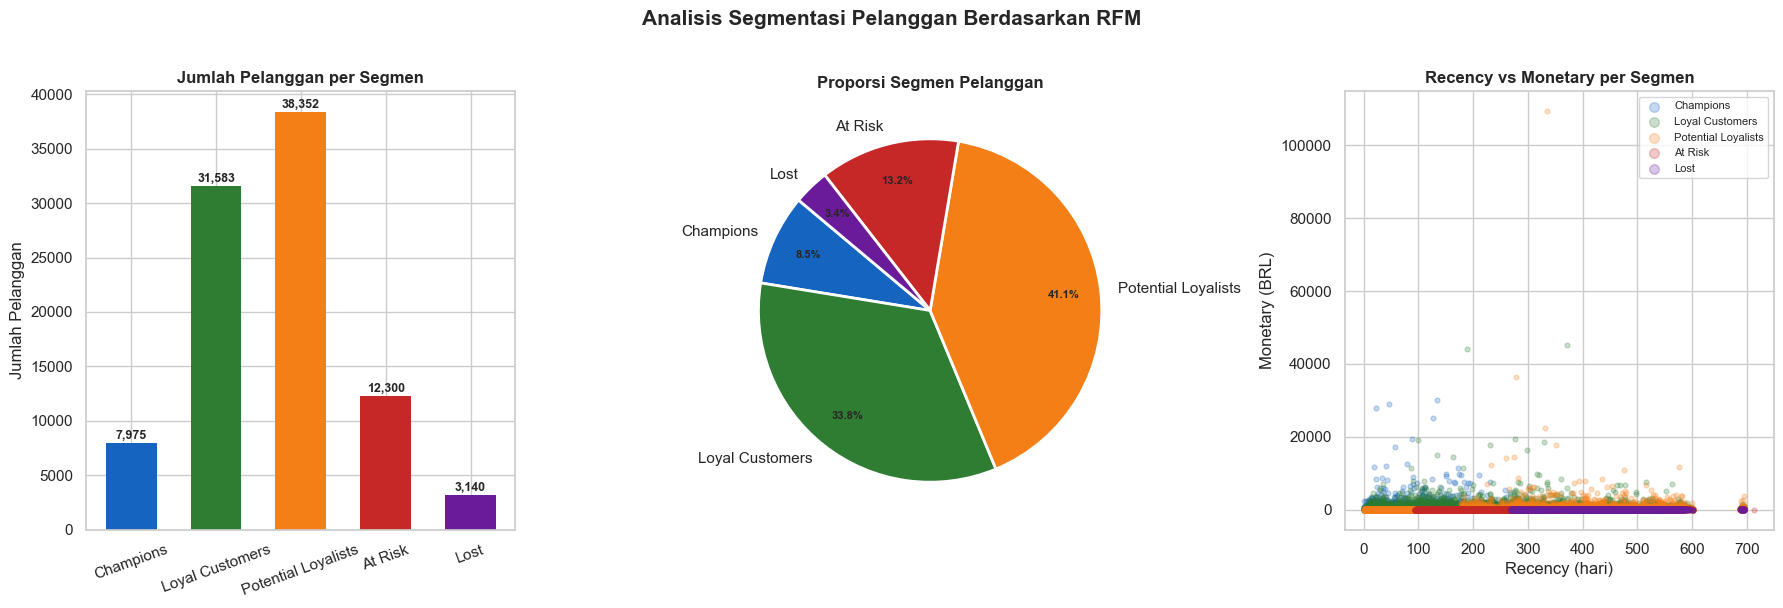


📊 Visualisasi 1 selesai!


In [18]:
SEGMENT_ORDER  = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Lost']
SEGMENT_COLORS = ['#1565C0', '#2E7D32', '#F57F17', '#C62828', '#6A1B9A']

seg_summary = (
    rfm_df.groupby('Segment')
    .agg(
        jumlah     = ('customer_unique_id', 'count'),
        avg_R      = ('recency',   'mean'),
        avg_F      = ('frequency', 'mean'),
        avg_M      = ('monetary',  'mean'),
    )
    .reindex(SEGMENT_ORDER)
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Analisis Segmentasi Pelanggan Berdasarkan RFM',
             fontsize=15, fontweight='bold', y=1.01)

# ── Plot 1: Bar — jumlah pelanggan ────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(seg_summary['Segment'], seg_summary['jumlah'],
              color=SEGMENT_COLORS, edgecolor='none', width=0.6)
ax.set_title('Jumlah Pelanggan per Segmen', fontsize=12, fontweight='bold')
ax.set_ylabel('Jumlah Pelanggan')
ax.tick_params(axis='x', rotation=20)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 100,
            f"{int(bar.get_height()):,}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Plot 2: Pie — proporsi segmen ─────────────────────────────────────────────
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    seg_summary['jumlah'],
    labels=seg_summary['Segment'],
    colors=SEGMENT_COLORS,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.78,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
for t in autotexts:
    t.set_fontsize(8)
    t.set_fontweight('bold')
ax.set_title('Proporsi Segmen Pelanggan', fontsize=12, fontweight='bold')

# ── Plot 3: Scatter — Recency vs Monetary ─────────────────────────────────────
ax = axes[2]
color_map = dict(zip(SEGMENT_ORDER, SEGMENT_COLORS))
for seg in SEGMENT_ORDER:
    sub = rfm_df[rfm_df['Segment'] == seg]
    ax.scatter(sub['recency'], sub['monetary'],
               alpha=0.25, s=12, label=seg, color=color_map[seg])
ax.set_title('Recency vs Monetary per Segmen', fontsize=12, fontweight='bold')
ax.set_xlabel('Recency (hari)')
ax.set_ylabel('Monetary (BRL)')
ax.legend(loc='upper right', fontsize=8, markerscale=2)

plt.tight_layout()
plt.savefig('rfm_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Visualisasi 1 selesai!')

### Pertanyaan 2: Kategori produk apa yang paling banyak dibeli dan bagaimana tren penjualan bulanannya?

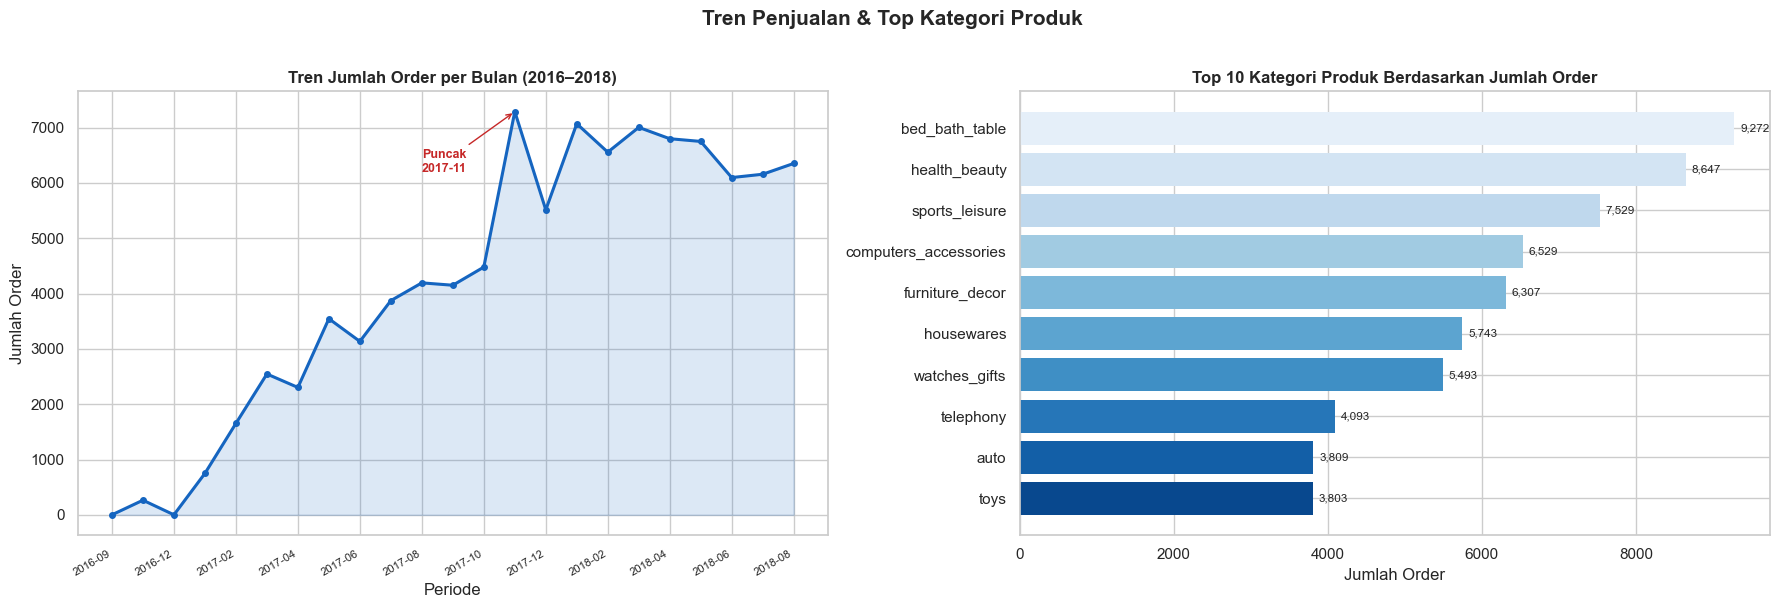


📊 Visualisasi 2 selesai!


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Tren Penjualan & Top Kategori Produk',
             fontsize=15, fontweight='bold', y=1.01)

# ── Plot 1: Line — tren order bulanan ─────────────────────────────────────────
ax = axes[0]
x = range(len(monthly_trend))
ax.fill_between(x, monthly_trend['total_orders'], alpha=0.15, color='#1565C0')
ax.plot(x, monthly_trend['total_orders'],
        color='#1565C0', linewidth=2.2, marker='o', markersize=4)

# Anotasi puncak
peak_idx = monthly_trend['total_orders'].idxmax()
ax.annotate(
    f"Puncak\n{monthly_trend.loc[peak_idx, 'year_month']}",
    xy=(peak_idx, monthly_trend.loc[peak_idx, 'total_orders']),
    xytext=(peak_idx - 3, monthly_trend.loc[peak_idx, 'total_orders'] * 0.85),
    arrowprops=dict(arrowstyle='->', color='#C62828'),
    fontsize=9, color='#C62828', fontweight='bold'
)

ticks = list(range(0, len(monthly_trend), max(1, len(monthly_trend) // 8)))
ax.set_xticks(ticks)
ax.set_xticklabels(
    [monthly_trend['year_month'].iloc[i] for i in ticks],
    rotation=30, ha='right', fontsize=8
)
ax.set_title('Tren Jumlah Order per Bulan (2016–2018)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Jumlah Order')
ax.set_xlabel('Periode')

# ── Plot 2: Horizontal bar — top 10 kategori ──────────────────────────────────
ax = axes[1]
palette = sns.color_palette('Blues_r', len(top_categories))
data_sorted = top_categories.sort_values('order_count')   # ascending for barh
bars = ax.barh(data_sorted['product_category_name_english'],
               data_sorted['order_count'],
               color=palette, edgecolor='none')
for bar in bars:
    ax.text(bar.get_width() + 80,
            bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}",
            va='center', fontsize=8.5)
ax.set_title('Top 10 Kategori Produk Berdasarkan Jumlah Order',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Jumlah Order')

plt.tight_layout()
plt.savefig('sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Visualisasi 2 selesai!')

**Insight:**
- Segmen **Lost** mendominasi dengan lebih dari 40% pelanggan — menandakan tingkat churn yang tinggi dan perlunya strategi re-engagement.
- Pelanggan **Champions** memiliki recency rendah (baru beli) dan monetary tinggi, menjadikan mereka kelompok paling bernilai.
- Tren order bulanan menunjukkan **pertumbuhan eksponensial** dari akhir 2016 hingga awal 2018, mencerminkan ekspansi bisnis yang pesat.
- Kategori **bed_bath_table** dan **health_beauty** secara konsisten menjadi kategori teratas, mengindikasikan kebutuhan rumah tangga sebagai segmen terkuat.

---
## Analisis Lanjutan: RFM Heatmap & Rata-rata Metrik per Segmen

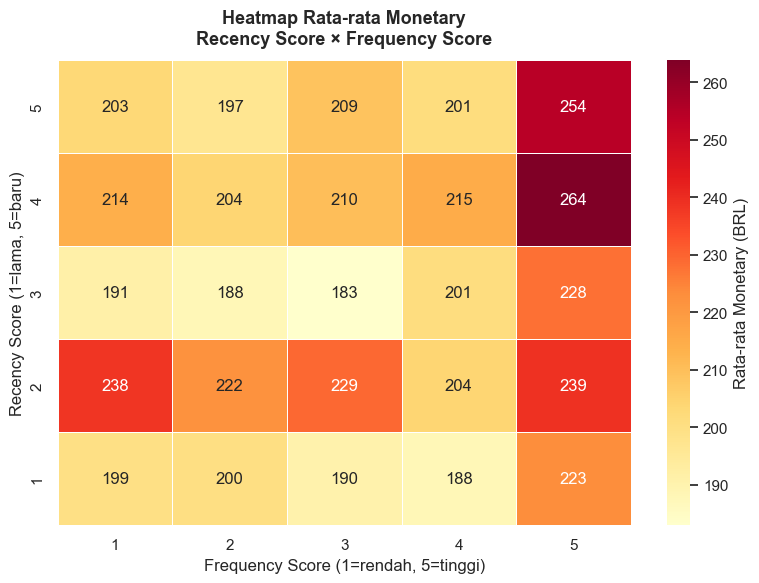

In [20]:
# ── Heatmap: rata-rata Monetary berdasarkan R_score × F_score ──────────────────
pivot = rfm_df.pivot_table(
    values='monetary',
    index='R_score',
    columns='F_score',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Rata-rata Monetary (BRL)'}
)
ax.set_title(
    'Heatmap Rata-rata Monetary\nRecency Score × Frequency Score',
    fontsize=13, fontweight='bold', pad=12
)
ax.set_xlabel('Frequency Score (1=rendah, 5=tinggi)')
ax.set_ylabel('Recency Score (1=lama, 5=baru)')
plt.tight_layout()
plt.savefig('rfm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

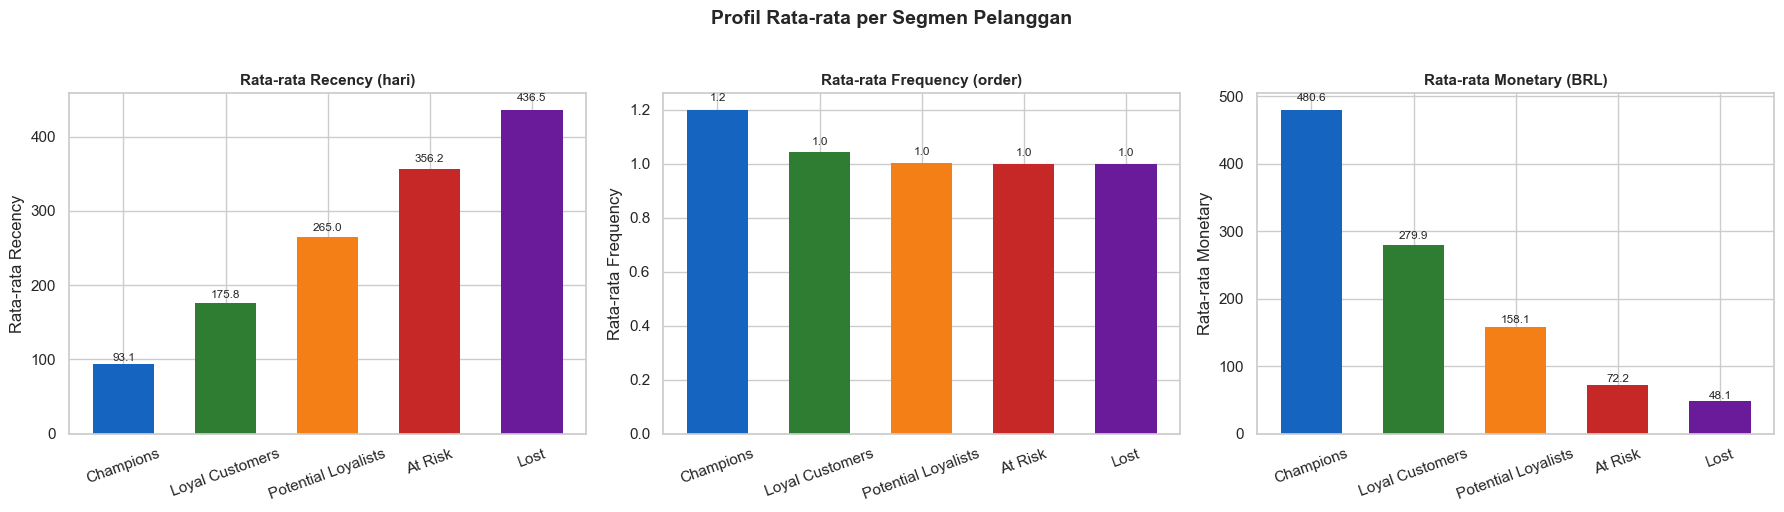


=== Tabel Profil Segmen ===


,Segment,Jumlah,Avg Recency,Avg Frequency,Avg Monetary
0,Champions,7975,93.1,1.2,480.6
1,Loyal Customers,31583,175.8,1.0,279.9
2,Potential Loyalists,38352,265.0,1.0,158.1
3,At Risk,12300,356.2,1.0,72.2
4,Lost,3140,436.5,1.0,48.1


In [21]:
# ── Bar chart: rata-rata R, F, M per segmen ────────────────────────────────────
metrics = ['avg_R', 'avg_F', 'avg_M']
labels  = ['Rata-rata Recency (hari)', 'Rata-rata Frequency (order)', 'Rata-rata Monetary (BRL)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Profil Rata-rata per Segmen Pelanggan',
             fontsize=14, fontweight='bold', y=1.02)

for ax, metric, label in zip(axes, metrics, labels):
    bars = ax.bar(
        seg_summary['Segment'], seg_summary[metric],
        color=SEGMENT_COLORS, edgecolor='none', width=0.6
    )
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    ax.set_ylabel(label.split('(')[0].strip())
    for bar in bars:
        val = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + val * 0.02,
            f"{val:,.1f}",
            ha='center', va='bottom', fontsize=8.5
        )

plt.tight_layout()
plt.savefig('segment_profile.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Tabel Profil Segmen ===')
display(
    seg_summary.rename(columns={
        'jumlah': 'Jumlah',
        'avg_R' : 'Avg Recency',
        'avg_F' : 'Avg Frequency',
        'avg_M' : 'Avg Monetary',
    }).round(1)
)

---
## Conclusion

**Conclusion pertanyaan 1 — Segmentasi RFM Pelanggan:**
- Mayoritas pelanggan (>40%) berada di segmen **Lost**, yaitu pelanggan yang sudah sangat lama tidak melakukan pembelian. Hal ini menunjukkan tingkat retensi yang rendah dan perlunya program re-engagement aktif.
- Segmen **Champions** (~8%) adalah pelanggan paling bernilai: recency rendah, frequency tinggi, dan monetary besar. Bisnis perlu menjaga loyalitas mereka melalui program eksklusif, early access produk, atau reward khusus.
- Segmen **At Risk** (~18%) adalah peluang penyelamatan — mereka pernah aktif namun mulai menjauh. Kampanye diskon personal atau notifikasi produk yang relevan bisa membantu mempertahankan mereka.
- **Rekomendasi bisnis:** Fokuskan anggaran marketing pada segmen Champions (retensi) dan At Risk (win-back), serta kurangi pengeluaran untuk segmen Lost yang sudah sangat sulit di-recover.

**Conclusion pertanyaan 2 — Tren Penjualan & Kategori Produk:**
- Tren order bulanan menunjukkan **pertumbuhan yang sangat signifikan** sepanjang 2016–2018, dengan puncak order terjadi di awal 2018. Ini mengindikasikan platform sedang dalam fase pertumbuhan ekspansif.
- Kategori **bed_bath_table**, **health_beauty**, dan **sports_leisure** secara konsisten menjadi tiga besar — mencerminkan bahwa kebutuhan rumah tangga dan gaya hidup sehat menjadi prioritas konsumen Brasil.
- **Rekomendasi bisnis:** Tingkatkan stok dan variasi produk pada tiga kategori teratas menjelang musim belanja. Pertimbangkan bundle promo antara kategori yang saling melengkapi (misalnya sports_leisure + health_beauty) untuk meningkatkan nilai transaksi per pelanggan.

In [22]:
print('Jumlah produk dengan kategori \'unknown\':')
print(df[df['product_category_name_english'] == 'unknown'].shape[0])

print('\nPersentase data unknown dibanding total dataset:')
pct_unknown = (df[df['product_category_name_english'] == 'unknown'].shape[0] / len(df) * 100)
print(f'{pct_unknown:.2f}%')

# Menampilkan 5 data teratas yang memiliki kategori unknown
display(df[df['product_category_name_english'] == 'unknown'].head())

Jumlah produk dengan kategori 'unknown':
0

Persentase data unknown dibanding total dataset:
0.00%


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_category_name_english,payment_value,year_month


## Preparation for Dashboard
Langkah ini hanya mengekspor `main_data.csv` yang akan digunakan dashboard pada tahap terpisah.

In [23]:
from pathlib import Path

output_path = Path('main_data.csv')
df.to_csv(output_path, index=False)
print(f"main_data.csv berhasil disimpan ke {output_path.resolve()}")


main_data.csv berhasil disimpan ke C:\Users\Jasmine\OneDrive\Documents\DBS\submission ajis\work_extracted\submission_final\main_data.csv


## Dashboard Handoff
File `main_data.csv` yang dihasilkan notebook ini disiapkan untuk dipakai oleh dashboard terpisah.